# || NEMO SANDBOX  ||
© _Konstantinos Andreadis_ (Roux Lab & Salbreux Lab @UNIGE)

In [337]:
# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation
from importlib import reload

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import os
import numpy as np
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import itertools
import trimesh
import scipy.spatial

>> Loading tif /Users/andreadi/Desktop/test.tif...
>> Applying 3D Gaussian blur with sigma = 1...
>> Re-Norming intensities...
>> Plotting a matrix...


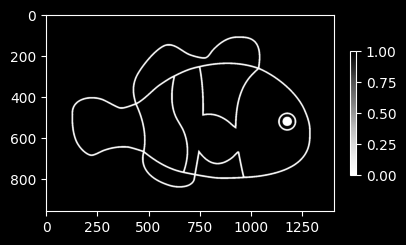

100%|██████████| 106/106 [00:00<00:00, 583.71it/s]


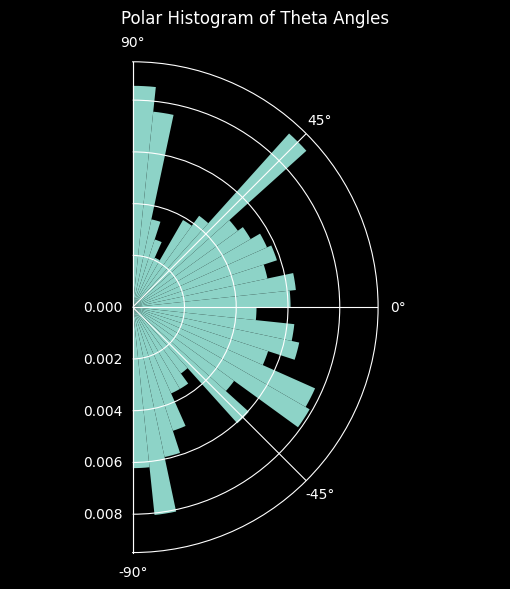

>> Plotting a matrix...


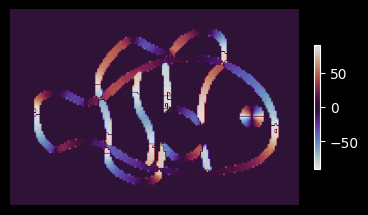

In [338]:
t = datahandler.load_tiff("/Users/andreadi/Desktop/test.tif")
t = np.pad(t, pad_width=100, constant_values=1)
t = analysis.normalise_range(t)
t[t > 0] = 1
t = analysis.gaussian_blur(t, 1, renorm=True)
visuals.plot_matrix(t, origin="upper", cmap="Greys", colorbar=True)
theta = analysis.compute_2d_orientation(mode="fibre", img=t, sampling_box_size=9, onlytheta=True)
visuals.plot_polar_hist(theta[theta != 0])
visuals.plot_matrix(theta, origin="upper", cmap="twilight", colorbar=True, remove_axes=True,
                    savefig="/Users/andreadi/Downloads/test.png")


# TOPOLOGICAL CHARGE CALCULATION

In [339]:
# mesh = trimesh.creation.icosphere(radius=1, subdivisions=3)
# visuals.plot_maxproj_pts(mesh.vertices, cmap="Greys", unit="??", hexsize=100)
mesh = trimesh.creation.uv_sphere(radius=1, subdivisions=1)

mesh_sel_mask = np.einsum('ij,ij->i', np.array([[0, 0, -1] for i in range(len(mesh.vertices))]),
                          mesh.vertex_normals) < 0  # >> CYLINDER
mesh = analysis.sel_submesh(mesh=mesh, mask=mesh_sel_mask)
x, y, z = mesh.vertices.T
r = np.linalg.norm(mesh.vertices, axis=1)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# RING
t1_x = -np.sin(phi)
t1_y = np.cos(phi)
t1_z = np.zeros_like(t1_x)

# ASTER
t1_x = np.cos(phi) * np.cos(theta)
t1_y = np.sin(phi) * np.cos(theta)
t1_z = -np.sin(theta)

directors = np.column_stack((mesh.vertices, t1_x, t1_y, t1_z))
directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)
directors = directors[mesh_sel_mask]

directors[:, :3] = mesh.vertices

# mesh.vertices[:, 2] = 0
# directors[:, 2] = 0
# directors[:, 5] = 0
# directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)

tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
# directors = np.column_stack((mesh.vertices, simulation.random_tangential(tan_x, tan_y)))
visuals.plot_dir_field(directors=directors, veclength=0.1)
visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
# visuals.view_mesh_and_vector_field(mesh_list=[mesh], directors=directors,
#                                    vec_length=0.1, vec_colors="red")

>> Identifying surfaces using mask...


IndexError: boolean index did not match indexed array along dimension 0; dimension is 961 but corresponding boolean dimension is 1922

>> Creating defects...
>> Generating parabolic_down surface..
>> Projection vector field onto surface...
>> Plotting director field...


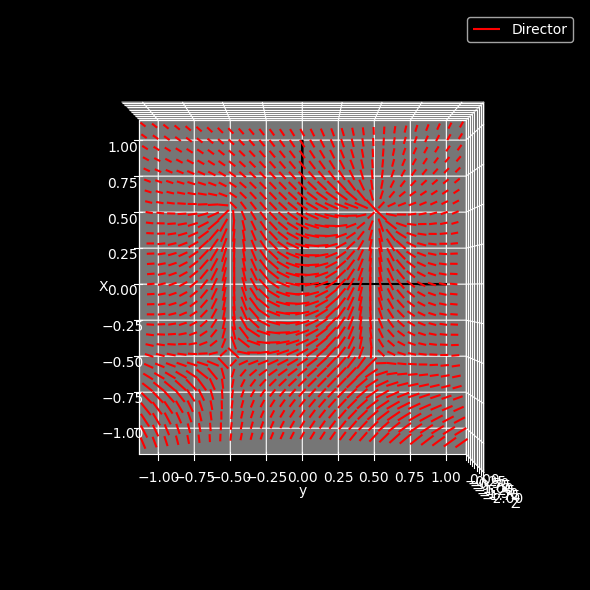

>> Averaging the nematic tensor in basis t1 t2 ...
>> Plotting director field...


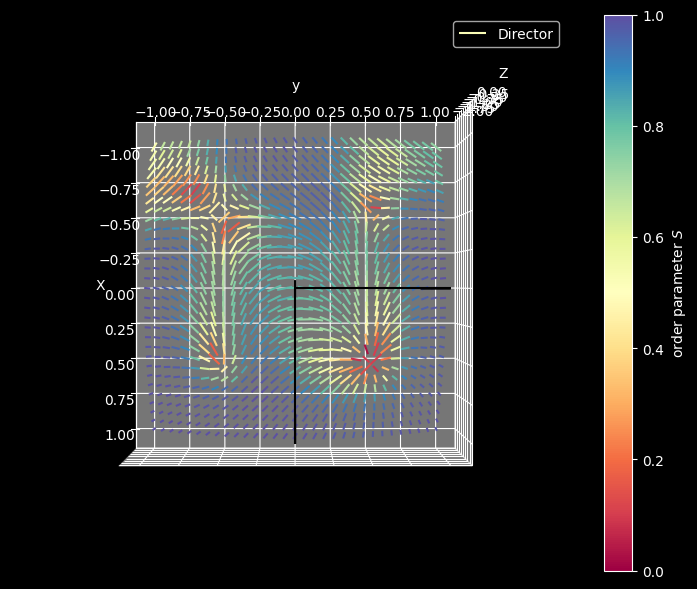

>> Plotting director field...


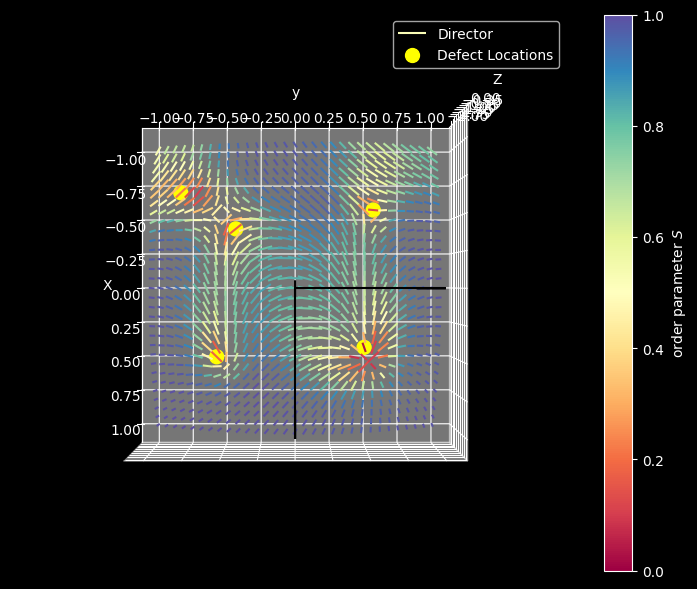

>> Calculating curvature for mesh with k=10 and 961 vertices...
>> Calculating topological charge for 961 directors...
Plotting histogram...


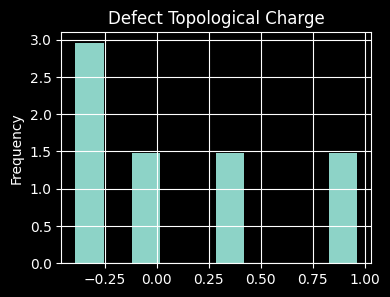

>> Plotting director field...


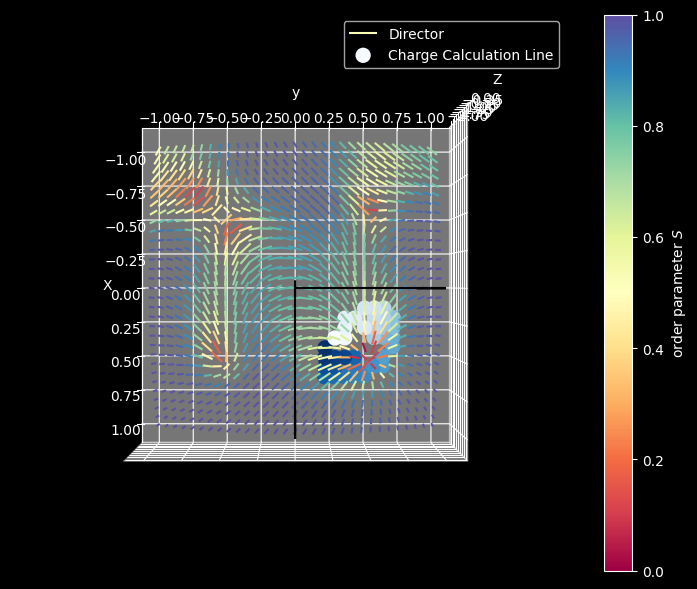

>> Plotting director field...


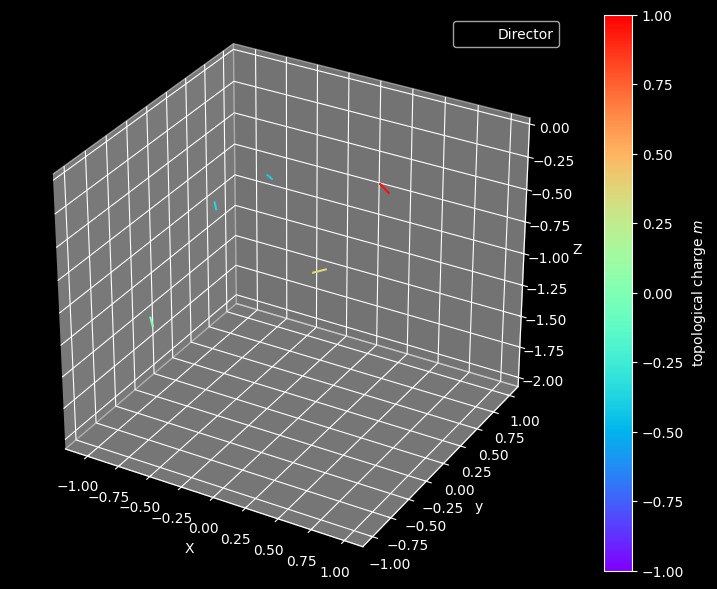

>> Rendering mesh and colored vertices...


In [315]:

# directors = np.column_stack((mesh.vertices, simulation.random_tangential(tan_x, tan_y)))
defects = [[0, 0, 1], [0.5, 0.5, 0.5]]
defects = [[0, 0, 1]]
a = 0.5
defects = [[-a, -a, -1], [-a, a, -0.5], [a, -a, 0.5], [a, a, 1]]
x, y, u, v = simulation.point_defect_2d_charge_multiple(l=1,
                                                        n=31, defects=defects)
directors = np.column_stack(
    (x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(), np.zeros_like(u.flatten())))
normals = np.zeros((directors.shape[0], 3))
normals[:, 2] = 1
mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                       faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)

z, dz_dx, dz_dy = simulation.generate_surface(mode="parabolic_down", x_=x, y_=y)
directors, normals = simulation.surface_warp(x, y, z, dz_dx, dz_dy, u, v)
mesh.vertices = directors[:, :3]
mesh.vertex_normals = normals

tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)

visuals.plot_dir_field(directors=directors, veclength=0.1, view_init=[-90, 0])
# visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
# visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
#                             vec_length=0.1, vec_colors="red")

k_order = 5 ** 2

S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                           neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                       k=k_order))
visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order, cmap_label="order parameter $S$",
                       manual_vminmax=[0, 1], view_init=[90, 0])

low_order_idxs = np.argsort(S_order)[:20]

target_num = 5
dist_cutoff = 0.8
defect_i_chosen = [0]

dist_matrix = np.array([
    [analysis.geodesic_distmesh(mesh, idx1, idx2, debug=False) for idx2 in low_order_idxs]
    for idx1 in low_order_idxs
])
for _ in range(1, target_num):
    remaining = np.setdiff1d(np.arange(len(low_order_idxs)), defect_i_chosen)
    min_distances = np.min(dist_matrix[remaining][:, defect_i_chosen], axis=1)
    next_choice = remaining[np.argmax(min_distances)]
    if np.all(dist_matrix[next_choice, defect_i_chosen] > dist_cutoff):
        defect_i_chosen.append(next_choice)
low_order_idxs = [low_order_idxs[idx] for idx in defect_i_chosen]

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1], view_init=[90, 0])

k_gauss = 10
k_charge = 7 ** 2  #len(mesh.vertices)
C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                            gauss_crop_range=None)
charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                            calc_idxs=low_order_idxs,
                                            director_indeces=np.arange(
                                                mesh.vertices.shape[0]),
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=1, k_charge=k_charge,
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
# print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
visuals.plot_hist(m_charge[~np.isnan(m_charge)], title="Defect Topological Charge")
visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][calc_charge_loop_idxs[0]],
                       pt_label="Charge Calculation Line", view_init=[90, 0],
                       pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
                                                     cmap="Blues"),
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
                       # savefig=f"/Users/andreadi/Downloads/curved-{defects}.png", view_init=[90, 0],
                       cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)
# inter_defect_dist = analysis.geodesic_distmesh(mesh=mesh, index1=low_order_idxs[0], index2=low_order_idxs[1],
#                                                debug=True)
visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors, verts=directors[:, :3][low_order_idxs], pts_size=20,
                            verts_colors="yellow",
                            # vec_colors=visuals.color_scalar(m_charge, cmap="rainbow", manual_vminmax=[-1, 1]),
                            # vec_colors="red",
                            vec_colors=visuals.color_scalar(S_order, cmap="Spectral", manual_vminmax=[0, 1]),
                            vec_length=0.08, vec_edge_width=0.01)

In [231]:
m_range = np.arange(-1, 1 + 0.125, 0.125)
k_charge_range = np.arange(10, len(mesh.vertices), 100)
k_charge_range = [200]
m_exp = []
m_res = []
k_charge_ = []
for m in m_range:
    for k_charge in k_charge_range:
        defects = [[0, 0, m]]
        x, y, u, v = simulation.point_defect_2d_charge_multiple(l=2,
                                                                n=31, defects=defects)
        directors = np.column_stack(
            (
                x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(),
                np.zeros_like(u.flatten())))
        normals = np.zeros((directors.shape[0], 3))
        normals[:, 2] = 1
        mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                               faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)
        tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
        # visuals.plot_dir_field(directors=directors, veclength=0.1, view_init=[-90, 0])
        # visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
        # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
        #                                    vec_length=0.1, vec_colors="red")
        S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                                   neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                               k=k_order))
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order, cmap_label="order parameter $S$",
        #                        manual_vminmax=[0, 1], view_init=[90, 0])
        low_order_idxs = np.argsort(S_order)
        # low_order_idxs = [480]
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1], view_init=[90, 0])

        k_gauss = 20
        C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                                    gauss_crop_range=None)
        charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                    calc_idxs=low_order_idxs,
                                                    director_indeces=np.arange(
                                                        mesh.vertices.shape[0]),
                                                    tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                    loop_angle_precision=1, k_charge=k_charge,
                                                    debug=False, return_all_contributions=True)
        m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
        print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
        #                        pt_label="Charge Calculation Line", view_init=[90, 0],
        #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
        #                                                      cmap="Blues"),
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
        #                cmap_label="topological charge $m$", manual_vminmax=[-1, 1], view_init=[90, 0], savefig=f"/Users/andreadi/Downloads/m-{m}_k-{k_charge}.png")
        if m > 0:
            m_res.append(np.nanmax(m_charge))
        else:
            m_res.append(np.nanmin(m_charge))
        m_exp.append(m)
        k_charge_.append(k_charge)
        break
m_res = np.array(m_res)
m_exp = np.array(m_exp)
k_charge_ = np.array(k_charge_)

>> Creating defects...
>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=200 | FOUND [ 0.089  0.014  0.016  0.014  0.019  0.019  0.023  0.023  0.028  0.033
  0.038  0.044  0.046  0.047  0.048  0.049  0.048  0.047  0.046  0.044
  0.038  0.033  0.028  0.023  0.023  0.019  0.019  0.014  0.016  0.014
  0.089  0.013  0.004  0.002  0.001  0.001  0.     0.001  0.001  0.
  0.     0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.
 -0.     0.     0.     0.     0.001  0.001 -0.     0.001  0.001  0.002
  0.004  0.013  0.015  0.002  0.    -0.    -0.     0.    -0.001 -0.001
 -0.001 -0.    -0.    -0.001 -0.001 -0.001 -0.001 -0.001 -0.001 -0.001
 -0.001 -0.001 -0.    -0.    -0.001 -0.001 -0.     0.    -0.    -0.
  0.     0.002  0.015  0.015  0.     0.    -0.001 -0.001 -0.001 -0.001
 -0.001 -0.001 -0.001 -0.002 -0.002 -0.001 -0.002 -0.003 -0.003 -0.003
 -0.002 -0.001 -0.001

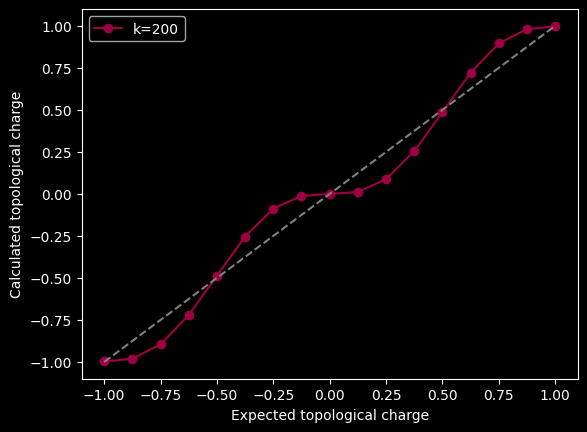

In [232]:
plt.figure()
colormap = plt.cm.Spectral
for idx, sel_k_charge in enumerate(np.unique(k_charge_)):
    select_k = k_charge_ == sel_k_charge
    color = colormap(idx / len(np.unique(k_charge_)))
    plt.plot(m_exp[select_k], m_res[select_k], "o-", label=f"k={sel_k_charge}", color=color)
plt.plot(m_range, m_range, "--", c="grey")
plt.xlabel("Expected topological charge")
plt.ylabel("Calculated topological charge")
plt.legend()
plt.show()

>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=50.0 | FOUND [1.88]
>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=151.22222222222223 | FOUND [1.975]
>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=252.44444444444446 | FOUND [1.982]
>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=353.6666666666667 | FOUND [1.982]
>> Averaging the nematic tensor in basis t1 t2 ...
>> Calculating curvature for mesh with k=20 and 961 vertices...
>> Calculating topological charge for 961 directors...
k=454.888888888888

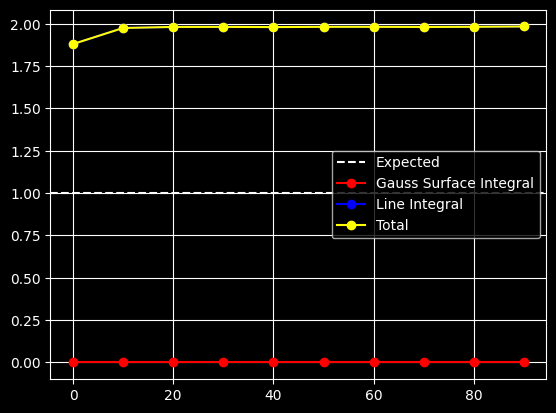

In [143]:
k_order = 3
k_gauss = 20
k_charge = 200  #len(mesh.vertices)
k_charge_range = np.linspace(50, len(mesh.vertices), 10)
# k_charge_range = [len(mesh.vertices)]
k_charges_ = []
m_charges_ = []
gauss_contributions_ = []
line_contributions_ = []
for k_charge in k_charge_range:
    S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                               neigh_idxs=analysis.coord_search_neighbours(verts=mesh.vertices,
                                                                                           k=k_order))
    low_order_idxs = np.argsort(S_order)[:1]
    C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                                gauss_crop_range=None)
    charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                calc_idxs=low_order_idxs,
                                                director_indeces=np.arange(
                                                    mesh.vertices.shape[0]),
                                                tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                loop_angle_precision=1, k_charge=k_charge,
                                                debug=False, return_all_contributions=True)
    m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
    print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")

    k_charges_.append(k_charge)
    m_charges_.append(m_charge[~np.isnan(m_charge)])
    gauss_contributions_.append(np.nanmean(m_gauss_contribution))
    line_contributions_.append(np.nanmean(m_line_charge))
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_hist(m_charge[~np.isnan(m_charge)], title="Defect Topological Charge")
    # visuals.plot_dir_field(directors=directors[:1], veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
    #                        pt_label="Charge Calculation Line",
    #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
    #                                                      cmap="Blues"),
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
    #                        cmap_label="topological charge $m$", manual_vminmax=[-1, 1])
    # inter_defect_dist = analysis.geodesic_distmesh(mesh=mesh, index1=low_order_idxs[0], index2=low_order_idxs[1],
    #                                                debug=True)
    # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
    #                             vec_colors=visuals.color_scalar(m_charge, cmap="hsv", manual_vminmax=[-1, 1]),
    #                             vec_length=0.1)
polar_angles = np.linspace(0, 1, len(gauss_contributions_)) * np.pi / 2
gauss_contribution = 1 - np.cos(polar_angles)
plt.figure()
plt.axhline(1.0, linestyle='--', color='white', label="Expected")
plt.plot(np.degrees(polar_angles), gauss_contributions_, "o-", c="red", label="Gauss Surface Integral")
plt.plot(np.degrees(polar_angles), line_contributions_, "o-", c="blue", label="Line Integral")
plt.plot(np.degrees(polar_angles), m_charges_, "o-", c="yellow", label="Total")
plt.grid()
plt.legend()
plt.show()


In [132]:
# visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors, vec_colors=visuals.color_scalar(S_order),
#                                    vec_length=0.1, verts=directors[:, :3][low_order_idxs], verts_colors="yellow")
# visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
#                             vec_colors=visuals.color_scalar(m_charge, cmap="hsv", manual_vminmax=[-1, 1]),
#                             vec_length=0.1)

In [ ]:
# control_folder = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/3_simulated/saddle-surface/data/1-defect/'
# control_directors = datahandler.load_array(name="directors", folderpath=control_folder)
# control_tan_x = datahandler.load_array(name="tan_x", folderpath=control_folder)
# control_tan_y = datahandler.load_array(name="tan_y", folderpath=control_folder)
# control_normals = np.cross(control_tan_x, control_tan_y)
# visuals.plot_dir_field(directors=control_directors, normals=control_normals, veclength=0.03)
# control_mesh = trimesh.Trimesh(vertices=control_directors[:, :3], vertex_normals=control_normals,
#                                faces=scipy.spatial.Delaunay(control_directors[:, :2]).simplices)



# Fusing

In [ ]:
img_path_1 = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250213_2p_actin-nuclei/1/d5_4_actin.tif"
img_raw_1, img_dim_1, img_scale_1, img_unit_1 = analysis.load_img(path=img_path_1, norm_vals=True, reduce_xy=1,
                                                                  reduce_z=1)
img_path_2 = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250213_2p_actin-nuclei/1/d5_6_actin.tif"
img_raw_2, img_dim_2, img_scale_2, img_unit_2 = analysis.load_img(path=img_path_2, norm_vals=True, reduce_xy=1,
                                                                  reduce_z=1)
img_raw_2 = np.flip(img_raw_2, axis=2)
img_raw_1 = img_raw_1[:-1]
if img_scale_1 != img_scale_2 or img_unit_1 != img_unit_2:
    print(">> Check: Unequal scaling and/or unit !!")
    img_scale, img_unit = None, None
else:
    img_scale, img_unit = img_scale_1, img_unit_1
    print(">> Check: All good to fuse !")
    visuals.plot_img(img_raw_1, scale=img_scale, unit=img_unit, cmap="Blues_r")
    visuals.plot_img(img_raw_2, scale=img_scale, unit=img_unit, cmap="Greens_r")
fused_image = np.maximum(img_cropped_1, img_flipped_2)
visuals.plot_img(fused_image, scale=img_scale, unit=img_unit, cmap="Spectral")

from scipy import ndimage

img_flipped_rotated_2 = ndimage.rotate(img_flipped_2, -3, reshape=False, axes=(2, 1))
fused_image = np.maximum(img_cropped_1, img_flipped_rotated_2)
visuals.plot_img(img_cropped_1, scale=img_scale, unit=img_unit, cmap="Greys_r",
                 thresh_mask=analysis.thresh_img(img_flipped_rotated_2,
                                                 analysis.yen_thresh(img_flipped_rotated_2[0])))
visuals.view_img(img_list=[img_raw_1, img_flipped_rotated_2], color_list=["green", "white"], opacity_list=[0.8, 0.8],
                 scale=img_scale)

# Elongation AXIS

>> Loading tif /Users/andreadi/Desktop/elongated_test.tif...
>> Plotting a matrix...


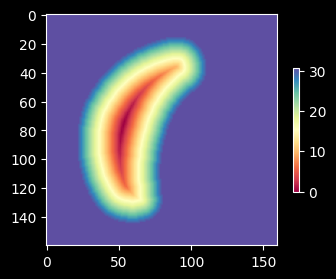

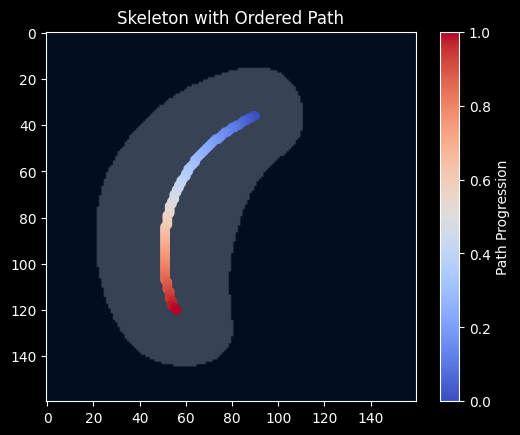

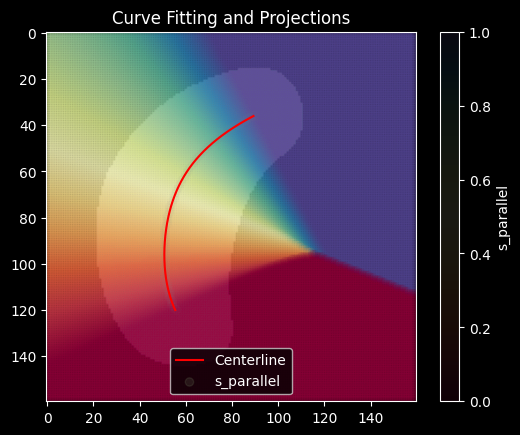

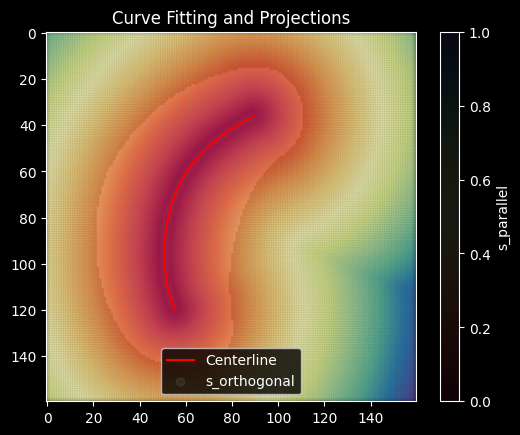

In [414]:
img = datahandler.load_tiff("/Users/andreadi/Desktop/elongated_test.tif")
img = analysis.normalise_range(img)
img = img[::100, ::100]
img[img > 0.1] = 1
img[img < 0.1] = 0
from skimage.graph import route_through_array
from scipy.ndimage import convolve
from skimage.morphology import medial_axis
from scipy.spatial import cKDTree


def find_skeleton_endpoints(skeleton):
    kernel = np.array([[1, 1, 1],
                       [1, 10, 1],
                       [1, 1, 1]])
    neighbor_count = convolve(skeleton.astype(int), kernel, mode="constant", cval=0)
    endpoints = np.argwhere((neighbor_count == 11) & (skeleton > 0))
    return [tuple(pt) for pt in endpoints]


def fit_centerline(path, num_points=500, degree_fit=4):
    x, y = path[:, 0], path[:, 1]
    model = np.poly1d(np.polyfit(x, y, degree_fit))
    polyline = np.linspace(x.min(), x.max(), num_points)
    centerline = np.column_stack((polyline, model(polyline)))
    return centerline


def project_to_curve(points, curve):
    tree = cKDTree(curve)
    dists, idxs = tree.query(points)
    closest_points = curve[idxs]
    s_parallel = np.cumsum(np.sqrt(np.sum(np.diff(curve, axis=0) ** 2, axis=1)))
    s_parallel = np.insert(s_parallel, 0, 0)
    s_proj = s_parallel[idxs]
    s_orthogonal = np.linalg.norm(points - closest_points, axis=1)
    return s_proj, s_orthogonal


skel, distance = medial_axis(img, return_distance=True)
endpoints = find_skeleton_endpoints(skel)
path_coords = np.array(route_through_array(1 - skel, endpoints[0], endpoints[-1], fully_connected=True)[0])
centerline = fit_centerline(path_coords)
coords = np.argwhere(~skel)
s_parallel, s_orthogonal = project_to_curve(coords, centerline)
s_parallel, s_orthogonal = analysis.normalise_range(1 - s_parallel), analysis.normalise_range(s_orthogonal)

visuals.plot_matrix(np.max(distance) - distance, colorbar=True, cmap="Spectral", origin="upper")
plt.figure()
plt.title("Skeleton with Ordered Path")
plt.imshow(img, alpha=0.3, cmap="Greys_r")
plt.imshow(skel, alpha=0.3, cmap="Blues_r")
plt.scatter(path_coords[:, 1], path_coords[:, 0], c=np.linspace(0, 1, len(path_coords)), cmap="coolwarm")
plt.colorbar(label="Path Progression")
plt.show()

plt.figure()
plt.imshow(img, cmap="gray", alpha=0.5)
plt.plot(centerline[:, 1], centerline[:, 0], "r-", label="Centerline")
plt.scatter(coords[:, 1], coords[:, 0], c=s_parallel, cmap="Spectral", label="s_parallel", alpha=0.1)
plt.colorbar(label="s_parallel")
plt.title("Curve Fitting and Projections")
plt.legend()
plt.show()
plt.imshow(img, cmap="gray", alpha=0.5)
plt.plot(centerline[:, 1], centerline[:, 0], "r-", label="Centerline")
plt.scatter(coords[:, 1], coords[:, 0], c=s_orthogonal, cmap="Spectral", label="s_orthogonal", alpha=0.1)
plt.colorbar(label="s_parallel")
plt.title("Curve Fitting and Projections")
plt.legend()
plt.show()

# Thickness

In [ ]:
mesh_1 = trimesh.creation.icosphere(radius=1, subdivisions=3)
mesh_2 = trimesh.creation.icosphere(radius=2, subdivisions=3)
mesh_2.vertices += [0, 0, 0.4]

# path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/ellipsoid_mx_main_clean/data/mesh_smooth.ply'
# mesh_1 = datahandler.load_mesh(path, recalc_normals=True)
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/ellipsoid_mx_main_clean/data/outer_mesh.ply"
# mesh_2 = datahandler.load_mesh(path, recalc_normals=True)
# mesh_1 = analysis.simplify_mesh(mesh_1, target_face_count=30000)
# mesh_2 = analysis.simplify_mesh(mesh_2, target_face_count=30000)

# path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/2_organoid/Position 1_Settings 1_fused/data/full_mesh_smooth.ply'
# mesh_1 = datahandler.load_mesh(path, recalc_normals=True)
# mesh_1 = analysis.simplify_mesh(mesh_1, target_face_count=30000)
# path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/2_organoid/Position 1_Settings 1_fused/data/OUTER_downsampled.ply'
# mesh_2 = datahandler.load_mesh(path, recalc_normals=True)

# path = "/Users/andreadi/Downloads/t0.ply"
# mesh_1 = datahandler.load_mesh(path, recalc_normals=True)
# path = "/Users/andreadi/Downloads/t75.ply"
# mesh_2 = datahandler.load_mesh(path, recalc_normals=True)
# analysis.mesh_properties(mesh_1, unit="px")
# analysis.mesh_properties(mesh_2, unit="px")

dist_vals, dist_idxs = analysis.inter_dist_mesh(mesh_1, mesh_2, debug=True)
visuals.plot_hist(dist_vals, bins=100)
visuals.view_mesh_and_verts(mesh_list=[mesh_1, mesh_2], mesh_colors=["white", "white"],
                            verts=mesh_1.vertices[dist_idxs],
                            verts_colors=visuals.color_scalar(dist_vals),
                            use_orig_color=True, verts_size=20)

# Curvature

In [ ]:
radius = 10
# mesh = trimesh.creation.icosphere(radius=radius, subdivisions=5)
# mesh = trimesh.creation.uv_sphere(radius=radius)
# mesh = trimesh.creation.capsule(radius=radius, height=radius)
# mesh = trimesh.creation.cone(radius=radius, height=radius)
# mesh = trimesh.creation.cylinder(radius=radius, height=3 * radius)
# mesh = trimesh.creation.capsule(radius=radius, height=3 * radius)
mesh = datahandler.load_mesh("/Users/andreadi/Downloads/nemo.ply", recalc_normals=True)
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Model/Meshes/tetrahedon.ply"
# path = "/Users/andreadi/Downloads/untitled.ply"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/2_organoid/Position 1_Settings 1_fused/data/full_mesh_smooth.ply"
# path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/ellipsoid_mx_main_clean/data/mesh_smooth.ply'

# path = "/Users/andreadi/Downloads/t0.ply"
# mesh = datahandler.load_mesh(path, recalc_normals=True)
# mesh = analysis.simplify_mesh(mesh, target_face_count=100000)
# mesh = analysis.subdivide_mesh(mesh, max_edge=0.4)

# mesh = analysis.simplify_mesh(mesh, remove_percent=0.5)
# mesh = analysis.smoothen_mesh(mesh, 300)

# visuals.view_mesh([mesh], hide_vectors=True)
# visuals.plot_maxproj_pts(mesh.vertices, cmap="Greys_r", unit="?")
# visuals.plot_dir_field(np.column_stack((mesh.vertices, mesh.vertex_normals)), normals=mesh.vertex_normals,
#                        aspect="auto", veclength=1, freq=10)

print(f"Gauss should be around {1 / np.ptp(mesh.vertices, axis=0).mean() ** 2:.3e}, "
      f"Mean should be around {1 / np.ptp(mesh.vertices, axis=0).mean():.3e}")
C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = analysis.curvature_by_srf_fit(mesh, k=50, debug=True,
                                                                           gauss_crop_range=None,
                                                                           mean_crop_range=None)
visuals.plot_hist(C_gauss, title="Gauss")
visuals.plot_hist(C_mean, title="Mean")
visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_gauss_idxs],
                            verts_colors=visuals.color_scalar(C_gauss), verts_size=0.4, use_orig_color=True,
                            mesh_colors="white")

visuals.plot_maxproj_pts(verts=mesh.vertices[C_mean_idxs], unit="?",
                         colors=analysis.normalise_range(C_mean), hexsize=100)
visuals.plot_maxproj_pts(verts=mesh.vertices[C_gauss_idxs], unit="?",
                         colors=analysis.normalise_range(C_gauss), hexsize=100)

In [ ]:

# visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_gauss_idxs],
#                             verts_colors=visuals.color_scalar(C_gauss), verts_size=1,
#                             use_orig_color=True,
#                             mesh_colors="white")
visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_mean_idxs],
                            verts_colors=visuals.color_scalar(C_mean), verts_size=1,
                            use_orig_color=True,
                            mesh_colors="white")

In [ ]:
radii = np.linspace(1, 10, 10)
C_gauss_all = []
C_mean_all = []
radii_all = []
for radius in radii:
    mesh = trimesh.creation.icosphere(radius=radius, subdivisions=4)
C_gauss, C_mean, _, _ = analysis.curvature_by_srf_fit(mesh, k=50)
C_gauss_all.append(C_gauss)
C_mean_all.append(C_mean)
radii_all.append(radius)

radii_all = np.asarray(radii_all)
C_gauss_all = np.asarray(C_gauss_all)
C_mean_all = np.asarray(C_mean_all)
C_gauss_avg = np.average(C_gauss_all, axis=1)
C_mean_avg = np.average(C_mean_all, axis=1)

C_gauss_expected = 1 / radii_all ** 2
C_mean_expected = 1 / radii_all
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
ax[0].plot(radii_all, C_gauss_avg, "x", label="Measured $C_{Gauss}$")
ax[0].plot(radii_all, C_gauss_expected, "--", label="Expected")
ax[1].plot(radii_all, C_mean_avg, "x", label="Measured $C_{Mean}$")
ax[1].plot(radii_all, C_mean_expected, "--", label="Expected")
ax[0].set_ylim(0, 1.2)
ax[1].set_ylim(0, 1.2)
ax[1].set_xlabel("Radius")
ax[0].legend()
ax[1].legend()
plt.show()

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
ax[0].plot(radii_all, (C_gauss_avg - C_gauss_expected) / C_gauss_expected ** 2, "x", label="$C_{Gauss}$ Relative Error")
ax[1].plot(radii_all, (C_mean_avg - C_mean_expected) / C_mean_expected, "x", label="$C_{Mean}$ Relative Error")
ax[1].set_xlabel("Radius")
ax[0].legend()
ax[1].legend()

# Geodesic Distance on Mesh

In [ ]:
mesh = trimesh.creation.icosphere(radius=1, subdivisions=4)
index1 = np.argwhere(mesh.vertices[:, 0] == mesh.vertices[:, 0].min())[0][0]
index2 = np.argwhere(mesh.vertices[:, 0] == mesh.vertices[:, 0].max())[0][0]
analysis.geodesic_distmesh(mesh, index1, index2, debug=True)
visuals.plot_dir_field(directors=np.column_stack((mesh.vertices, mesh.vertices)), veclength=0.1,
                       veccolor="red",
                       marker=mesh.vertices[[index1, index2]],
                       pt_label="Points",
                       pt_alpha=1.0, cmap_label="order parameter $S$")

In [ ]:
# img = np.zeros(shape=(100, 100))
# figsize = (10, 10)
# boxsize = 2
# mask_thresh_val = 0.3
# nem_analysis_neigh_num = 3 ** 3
# x, y = np.meshgrid(range(len(img)), range(len(img)))
# img[abs(np.sqrt((x - len(img) // 2) ** 2 + (y - len(img) // 2) ** 2) - 20) < 1] = 1
# img = analysis.gaussian_blur(img, sigma=2, renorm=False)
# visuals.plot_matrix(img, aspect=1, cmap='Greys_r', colorbar=True, title='Intensity Profile')
# orient2d_results = analysis.orient2d(img=img, boxsize=boxsize,
#                                      thresh_val=mask_thresh_val,
#                                      num_neigh_nem=nem_analysis_neigh_num, log_debug=False)
# theta_all_deg, theta_masked_rad, S_2d, n_2d, X, Y = orient2d_results
# visuals.plot_matrix(theta_all_deg, aspect=1, cmap='twilight', colorbar=True,
#                     title=f'Theta Angles for block {boxsize}x{boxsize}')
# visuals.plot_polar_hist(angles_deg=theta_all_deg)
# visuals.plot_matrix_vectors(Y, X, theta_masked_rad.T, img, title="Intensity Profile + Directors",
#                             veclength=0.1, vescale=300, vec_colors=S_2d,
#                             cbar_matrix_label="Intensity Signal (a.u.)", cbar_vector_label="order parameter $S$")
# visuals.plot_hist(array=S_2d, title="order parameter $S$")
# # visuals.plot_polar_hist(angles_deg=np.linspace(-90, 90, 30))

In [ ]:
# vec_posdir = np.array([[0, -0.1, 0, 1, 0.1, 0], [0, 0.1, 0, 0, 1, 0]])
# t1_raw = np.array([[-1, 0, 0], [-1, 1, 0]])
# t2_raw = np.array([[0, 1, 0], [1, 1, 0]])
# t1_raw = t1_raw / np.linalg.norm(t1_raw, axis=1, keepdims=True)
# t2_raw = t2_raw / np.linalg.norm(t2_raw, axis=1, keepdims=True)
# # res = np.array([analysis.covariant2contravariant(t1_raw[i], t2_raw[i]) for i in range(len(t1_raw))])
# # res1, res2 = res[:, 0, :], res[:, 1, :]
# n_vecs = vec_posdir[:, 3:]
# n_vecs = n_vecs / np.linalg.norm(n_vecs, axis=1, keepdims=True)
# import matplotlib.pyplot as plt
#
# plt.style.use('default')
# neigh_idxs = analysis.coord_search_neighbours(vec_posdir[:, :3], k=len(vec_posdir), n_process=8)
# S_order, n_avg = analysis.avg_nem_tens(t1_cov=t1_raw, t2_cov=t2_raw, directors=vec_posdir,
#                                        neigh_idxs=neigh_idxs, debug=False)
# print(f"S_order = {S_order}")
# print(f"n_avg = {n_avg}")
# visuals.plot_dir_field(vec_posdir, t1_raw, t2_raw, view_init=(70, 0), veclength=0.1, show_axes=False, aspect="auto",
#                        xlim=[-0.4, 0.1], ylim=[-0.2, 0.2])
# visuals.plot_dir_field(np.column_stack((vec_posdir[:, :3], n_avg)), t1_raw, t2_raw, view_init=(70, 0), veclength=0.1,
#                        show_axes=False, aspect="auto", xlim=[-0.4, 0.1], ylim=[-0.2, 0.2])

# vec_posdir = np.array([[-0.1, 0.1, 0, -1, 1, 0],
#                        [-0.1, -0.1, 0, -1, -1, 0],
#                        [0.1, 0.1, 0, 1, 1, 0],
#                        [0.1, -0.10, 0, 1, -1, 0]])
# t1_raw = vec_posdir[:, 3:]
# t2_raw = np.array([np.cross(t1_raw[i], [0, 0, 1]) for i in range(len(vec_posdir))])
# t1_raw = t1_raw / np.linalg.norm(t1_raw, axis=1, keepdims=True)
# t2_raw = t2_raw / np.linalg.norm(t2_raw, axis=1, keepdims=True)
# # res = np.array([analysis.covariant2contravariant(t1_raw[i], t2_raw[i]) for i in range(len(t1_raw))])
# # res1, res2 = res[:, 0, :], res[:, 1, :]
# n_vecs = vec_posdir[:, 3:]
# n_vecs = n_vecs / np.linalg.norm(n_vecs, axis=1, keepdims=True)
# plt.style.use('default')
# neigh_idxs = analysis.coord_search_neighbours(vec_posdir[:, :3], k=len(vec_posdir), n_process=8)
# S_order, n_avg = analysis.avg_nem_tens(t1_cov=t1_raw, t2_cov=t2_raw, directors=vec_posdir,
#                                        neigh_idxs=neigh_idxs)
# print(f"S_order = {S_order}")
# print(f"n_avg = {n_avg}")
# visuals.plot_dir_field(vec_posdir, t1_raw, t2_raw, view_init=(45, 30), veclength=0.1, show_axes=False, aspect="auto",
#                        xlim=[-0.4, 0.2], ylim=[-0.3, 0.2])
# visuals.plot_dir_field(np.column_stack((vec_posdir[:, :3], n_avg)), t1_raw, t2_raw, view_init=(45, 30), veclength=0.1,
#                        show_axes=False, aspect="auto", xlim=[-0.4, 0.2], ylim=[-0.3, 0.2])

# x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=[[0, 0, -1], [-1, 0, 0]])
# visuals.plot_vector_field(x,y,u,v,defect="multiple")

In [ ]:
# # ============ Fit an ellipsoid ============
# pts_to_fit = mesh.vertices
# ellips_params = analysis.fit_ellipsoid(points=inner_verts)
# x0, y0, z0, a, b, c, alpha, beta, gamma = ellips_params
#
# ellips_params = x0, y0, z0, a, b, c, alpha, beta, gamma
# ellips_num = 400000
# ellipsoid_verts, ellipsoid_normals = analysis.generate_ellipsoid(params=ellips_params, num_points=ellips_num)
# visuals.view_img_ref_verts(img=img_raw, pts=ellipsoid_verts, refpts=pts_to_fit, scale=img_scale, hide_img=True)

In [ ]:
# box_size = 10
# box_num = 10
# k = 4
# xx, yy = np.meshgrid(np.linspace(-box_size / 2, box_size / 2, box_num),
#                      np.linspace(-box_size / 2, box_size / 2, box_num))
# xx2, yy2 = np.meshgrid(np.linspace(-box_size / 2, box_size / 2, box_num // 2),
#                        np.linspace(-box_size / 2, box_size / 2, box_num // 2))
# X_combined = np.unique(np.concatenate((xx.ravel(), xx2.ravel())))
# Y_combined = np.unique(np.concatenate((yy.ravel(), yy2.ravel())))
# X_new, Y_new = np.meshgrid(X_combined, Y_combined)
# xcords, ycords = X_new.ravel(), Y_new.ravel()
# cords = np.column_stack((xcords, ycords))
# idxs, dists = analysis.coord_search_neighbours(cords, k=k, return_dists=True)
# dists = dists[:, 1:]
# densities = k / np.average(dists, axis=1)
#
# cmap = "coolwarm"
# plt.figure()
# plt.scatter(xcords, ycords, c=densities, cmap=cmap)
# plt.gca().set_aspect("equal")
# plt.colorbar(cmap=cmap, label="Density Estimate")
# plt.show()
#
# visuals.plot_hist(densities, xlim=None)

In [ ]:

# from skimage.filters import try_all_threshold
# fig, ax = try_all_threshold(img_raw[40], figsize=(10, 10), verbose=False)